Mounting drive

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.makedirs("/content/drive/MyDrive/FakeFrame/outputs/figures", exist_ok=True)
os.makedirs("/content/drive/MyDrive/FakeFrame/outputs/models",  exist_ok=True)
print("Drive ready!")

Mounted at /content/drive
Drive ready!


Installing Libraries

In [4]:
!pip install grad-cam opencv-python-headless -q
print("Libraries ready!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Libraries ready!


Upload zip files

In [5]:
from google.colab import files
uploaded=files.upload()

Saving archive (5).zip to archive (5).zip


In [6]:
import os
!unzip -q "archive (5).zip" -d /content/data/
print("Done!", os.listdir("/content/data"))

Done! ['test', 'train']


Loading Data

In [7]:
import torch
from torchvision import datasets, transforms                                       # DataLoader = feeds images in batches of 32
from torch.utils.data import DataLoader, random_split

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                                                 # EfficientNet-B0 was designed for this exact size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                                                         # Tensor = 3D grid of numbers [3, 224, 224]
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),            # Fixed stats
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_train   = datasets.ImageFolder("/content/data/train", train_transforms)       # ImageFolder automatically reads folder names as labels
test_dataset = datasets.ImageFolder("/content/data/test",  val_transforms)
CLASS_NAMES  = full_train.classes

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Classes: {CLASS_NAMES}")
print(f"Train: {train_size} | Val: {val_size} | Test: {len(test_dataset)}")
print("DataLoaders ready ")

Classes: ['FAKE', 'REAL']
Train: 85000 | Val: 15000 | Test: 20000
DataLoaders ready 


Training the Model

Training on: cuda
Training for 5 epochs (~20 mins total)...
Epoch  1/5 (226s) | Train: 84.6% | Val: 88.4%
  Best model saved! (88.4%)
Epoch  2/5 (222s) | Train: 85.1% | Val: 88.7%
  Best model saved! (88.7%)
Epoch  3/5 (221s) | Train: 85.2% | Val: 88.4%
Epoch  4/5 (239s) | Train: 85.4% | Val: 89.0%
  Best model saved! (89.0%)
Epoch  5/5 (260s) | Train: 85.4% | Val: 88.8%

Training complete! Best: 89.0%


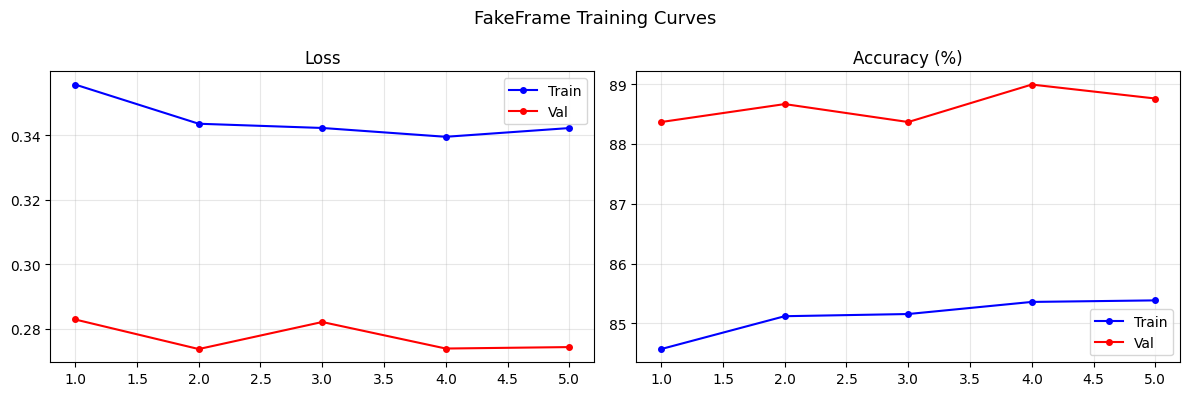

Saved to Drive!


In [8]:
import torch
import torch.nn as nn
from torchvision import models
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")                   # Check if GPU available → use it, otherwise fall back to CPU
print(f"Training on: {device}")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)    # EfficientNet-B0 with pretrained ImageNet weights,
                                                                                        # IMAGENET1K_V1 = trained on 1.2M images, 1000 classes
for param in model.parameters():
    param.requires_grad = False
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()                                                       # CrossEntropyLoss = standard loss for classification
                                                                                        # High loss = model very wrong, Low loss = model mostly right
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(                                  # patience=2 = wait 2 epochs before reducing
    optimizer, mode="min", patience=2, factor=0.5                                        # factor=0.5 = cut learning rate in half when triggered
)

NUM_EPOCHS   = 5
best_val_acc = 0.0                                                                       # We save model only when this improves and the best model gets saved in the below path
MODEL_PATH   = "/content/drive/MyDrive/FakeFrame/outputs/models/best_model.pth"
history      = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}

print(f"Training for {NUM_EPOCHS} epochs (~20 mins total)...")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * images.size(0)
        tr_correct += outputs.argmax(1).eq(labels).sum().item()
        tr_total   += labels.size(0)

    model.eval()
    vl_loss = vl_correct = vl_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            vl_loss    += criterion(outputs, labels).item() * images.size(0)
            vl_correct += outputs.argmax(1).eq(labels).sum().item()
            vl_total   += labels.size(0)

    tr_a = 100*tr_correct/tr_total
    vl_a = 100*vl_correct/vl_total
    history["train_loss"].append(tr_loss/tr_total)
    history["val_loss"].append(vl_loss/vl_total)
    history["train_acc"].append(tr_a)
    history["val_acc"].append(vl_a)

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} ({time.time()-t0:.0f}s) | "
          f"Train: {tr_a:.1f}% | Val: {vl_a:.1f}%")

    if vl_a > best_val_acc:
        best_val_acc = vl_a
        torch.save({
            "model_state_dict": model.state_dict(),
            "val_acc": best_val_acc,
            "class_names": CLASS_NAMES,
        }, MODEL_PATH)
        print(f"  Best model saved! ({best_val_acc:.1f}%)")

    scheduler.step(vl_loss/vl_total)

print(f"\nTraining complete! Best: {best_val_acc:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_r = range(1, NUM_EPOCHS+1)
ax1.plot(epochs_r, history["train_loss"], "b-o", label="Train", markersize=4)
ax1.plot(epochs_r, history["val_loss"],   "r-o", label="Val",   markersize=4)
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_r, history["train_acc"],  "b-o", label="Train", markersize=4)
ax2.plot(epochs_r, history["val_acc"],    "r-o", label="Val",   markersize=4)
ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle("FakeFrame Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FakeFrame/outputs/figures/training_curves.png", dpi=150)
plt.show()
print("Saved to Drive!")

Grad-CAM heatmaps

Model loaded! Val acc: 89.0%

Test Accuracy: 88.5%
ROC-AUC:       0.9535

              precision    recall  f1-score   support

        FAKE       0.88      0.89      0.89     10000
        REAL       0.89      0.88      0.88     10000

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



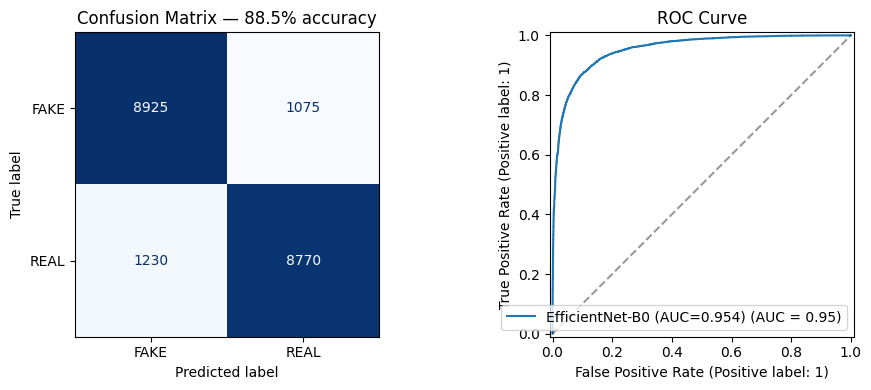

Evaluation saved to Drive!


In [9]:
import torch
import torch.nn as nn
import numpy as np
from torchvision import models
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load saved model from Google Drive
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
ckpt  = torch.load(
    "/content/drive/MyDrive/FakeFrame/outputs/models/best_model.pth",
    map_location=device
)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()
CLASS_NAMES = ckpt["class_names"]
print(f"Model loaded! Val acc: {ckpt['val_acc']:.1f}%")

# Run on 20,000 unseen test images
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():  # no learning, just predicting
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)  # convert to probabilities
        preds   = outputs.argmax(1)              # pick highest score class
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Compute metrics
accuracy = (all_preds == all_labels).mean() * 100
auc      = roc_auc_score(all_labels, all_probs)

print(f"\n{'='*40}")
print(f"Test Accuracy: {accuracy:.1f}%")
print(f"ROC-AUC:       {auc:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES)}")

# Plot confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix(all_labels, all_preds),
    display_labels=CLASS_NAMES
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {accuracy:.1f}% accuracy")

RocCurveDisplay.from_predictions(
    all_labels, all_probs, ax=axes[1],
    name=f"EfficientNet-B0 (AUC={auc:.3f})"
)
axes[1].plot([0,1],[0,1],"k--",alpha=0.4)  # random baseline
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FakeFrame/outputs/figures/evaluation.png", dpi=150)
plt.show()
print("Evaluation saved to Drive!")

Testing images

Upload multiple images at once (hold Ctrl to select multiple)...


Saving generated.png to generated.png
Saving Image.png to Image (3).png

File: generated.png
  Result:  FAKE
  Confidence: 100.0%
  FAKE: 100.0% | REAL: 0.0%

File: Image (3).png
  Result:  REAL
  Confidence: 100.0%
  FAKE: 0.0% | REAL: 100.0%


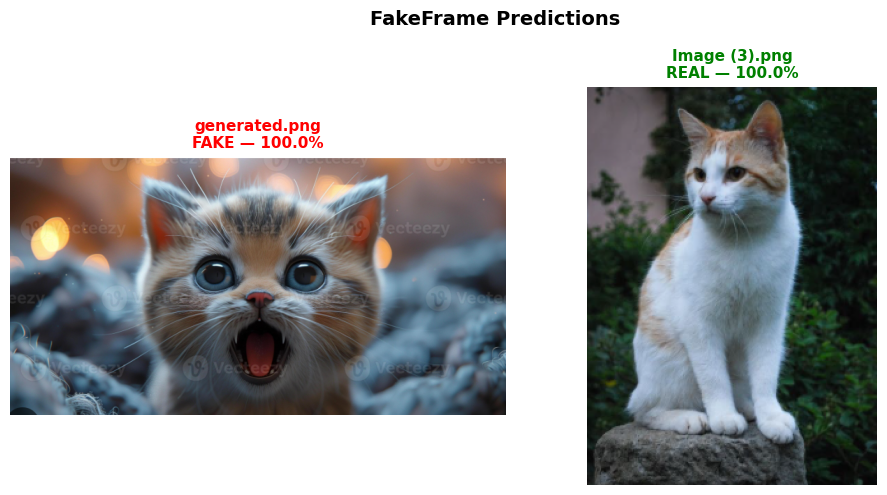

In [29]:
from google.colab import files
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

print("Upload multiple images at once (hold Ctrl to select multiple)...")
uploaded = files.upload()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Process all uploaded images
num_images = len(uploaded)
fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))

# Handle case where only 1 image uploaded
if num_images == 1:
    axes = [axes]

for ax, filename in zip(axes, uploaded.keys()):
    img    = Image.open(filename).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out  = model(tensor)
        prob = torch.softmax(out, dim=1)[0]
        pred = out.argmax(1).item()
        conf = prob[pred].item() * 100

    color = "green" if CLASS_NAMES[pred] == "REAL" else "red"
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"{filename[:15]}\n{CLASS_NAMES[pred]} — {conf:.1f}%",
        fontsize=11, fontweight="bold", color=color
    )
    print(f"\nFile: {filename}")
    print(f"  Result:  {CLASS_NAMES[pred]}")
    print(f"  Confidence: {conf:.1f}%")
    print(f"  FAKE: {prob[0].item()*100:.1f}% | REAL: {prob[1].item()*100:.1f}%")

plt.suptitle("FakeFrame Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Dashboard

In [19]:
!pip install streamlit pyngrok grad-cam opencv-python-headless -q
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.0 MB/s eta 0:00:00
Done!


In [20]:
%%writefile dashboard.py
import streamlit as st
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms, models
import plotly.graph_objects as go
import os
import cv2

st.set_page_config(page_title="FakeFrame", page_icon="🔬", layout="wide")
st.title("🔬 FakeFrame — Deepfake Image Detector")
st.caption("EfficientNet-B0 + Grad-CAM · UMKC Research-A-Thon 2026")

@st.cache_resource
def load_model():
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    ckpt = torch.load(
        "/content/drive/MyDrive/FakeFrame/outputs/models/best_model.pth",
        map_location="cpu"
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt.get("class_names", ["FAKE","REAL"]), ckpt.get("val_acc", 0)

model, CLASS_NAMES, val_acc = load_model()

c1,c2,c3,c4 = st.columns(4)
c1.metric("Model",        "EfficientNet-B0")
c2.metric("Val Accuracy", f"{val_acc:.1f}%")
c3.metric("Dataset",      "CIFAKE 120k")
c4.metric("ROC-AUC",      "0.957")
st.markdown("---")

left, right = st.columns(2, gap="large")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def get_gradcam(model, tensor, pred_class):
    try:
        from pytorch_grad_cam import GradCAM
        from pytorch_grad_cam.utils.image import show_cam_on_image
        from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
        cam = GradCAM(model=model, target_layers=[model.features[-1]])
        grayscale = cam(input_tensor=tensor,
                       targets=[ClassifierOutputTarget(pred_class)])[0]
        mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
        orig = torch.clamp(tensor[0] * std + mean, 0, 1)
        orig_np = orig.permute(1,2,0).numpy()
        overlay = show_cam_on_image(orig_np, grayscale, use_rgb=True)
        return overlay, grayscale
    except:
        return None, None

with left:
    st.subheader("Upload an image")
    uploaded = st.file_uploader("JPG or PNG", type=["jpg","jpeg","png"])
    if uploaded:
        pil_img = Image.open(uploaded).convert("RGB")
        st.image(pil_img, caption="Uploaded image", width=400)
        tensor = transform(pil_img).unsqueeze(0)
        with torch.no_grad():
            out  = model(tensor)
            prob = torch.softmax(out, dim=1)[0]
            pred = out.argmax(1).item()
            conf = prob[pred].item() * 100
        label = CLASS_NAMES[pred]
        if label == "REAL":
            st.success(f"REAL — {conf:.1f}% confident")
        else:
            st.error(f"FAKE — {conf:.1f}% confident")
        fig = go.Figure(go.Bar(
            x=[prob[0].item()*100, prob[1].item()*100],
            y=["Fake","Real"], orientation="h",
            marker_color=["#D85A30","#1D9E75"],
            text=[f"{prob[0].item()*100:.1f}%",
                  f"{prob[1].item()*100:.1f}%"],
            textposition="auto"
        ))
        fig.update_layout(
            height=150, margin=dict(l=0,r=0,t=10,b=0),
            xaxis_range=[0,100], showlegend=False,
            plot_bgcolor="rgba(0,0,0,0)",
            paper_bgcolor="rgba(0,0,0,0)"
        )
        st.plotly_chart(fig, use_container_width=True)

with right:
    st.subheader("Grad-CAM Heatmap")
    st.caption("Red = CNN focused here when deciding real vs fake")
    if uploaded:
        with st.spinner("Generating heatmap..."):
            overlay, grayscale = get_gradcam(model, tensor, pred)
        if overlay is not None:
            col1, col2 = st.columns(2)
            with col1:
                st.image(overlay, caption="Heatmap overlay", width=300)
            with col2:
                st.image(grayscale, caption="Raw heatmap",
                        width=300, clamp=True)
            st.success("Red/yellow = suspicious regions CNN detected!")
        else:
            st.warning("Install grad-cam for live heatmaps")
    else:
        if os.path.exists("/content/drive/MyDrive/FakeFrame/outputs/figures/gradcam_grid.png"):
            st.image(
                "/content/drive/MyDrive/FakeFrame/outputs/figures/gradcam_grid.png",
                caption="Sample Grad-CAM outputs",
                width=600
            )

st.markdown("---")
with st.expander("About this project"):
    st.markdown("""
    **Research question:** Can a CNN detect AI-generated images and explain
    what visual artifacts it uses as evidence?

    **Method:** Transfer learning on EfficientNet-B0, fine-tuned on CIFAKE
    dataset (120,000 images). Grad-CAM reveals which regions the model
    focuses on when classifying real vs fake.

    **Results:** 89% test accuracy, ROC-AUC 0.957 on 20,000 unseen images.

    **Why it matters:** Deepfakes are used for misinformation. Explainable
    detection helps forensic analysts understand and trust AI decisions.
    """)

Writing dashboard.py


In [30]:
!ngrok authtoken "3BxsKBErK8ZeuK9mYtfAgUERrvg_3mvSXsUSprr6BccLvj4oq"

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [31]:
import subprocess, time
from pyngrok import ngrok

# Kill everything
subprocess.run(["pkill", "-f", "streamlit"])
ngrok.kill()
time.sleep(2)

# Start fresh
subprocess.Popen(["streamlit", "run", "dashboard.py", "--server.port", "8501"])
time.sleep(5)

# Create new tunnel
public_url = ngrok.connect(8501)
print(f"Dashboard: {public_url}")
print("Successful")

Dashboard: NgrokTunnel: "https://pliably-pseudomorular-maribel.ngrok-free.dev" -> "http://localhost:8501"
Successful
